# Introduction to Data Science 2026

# Week 6: Recap

## Exercise 1 | Linear regression with feature selection

Download the [TED Talks](https://www.kaggle.com/rounakbanik/ted-talks) dataset from Kaggle. Your task is to predict both the ratings and the number of views of a given TED talk. You should focus only on the <span style="font-weight: bold">ted_main</span> table.

1. Download the data, extract the following ratings from column <span style="font-weight: bold">ratings</span>: <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, <span style="font-weight: bold">Inspiring</span>. Store these values into respective columns so that they are easier to access. Next, extract the tags from column <span style="font-weight: bold">tags</span>. Count the number of occurrences of each tag and select the top-100 most common tags. Create a binary variable for each of these and include them in your data table, so that you can directly see whether a given tag (among the top-100 tags) is used in a given TED talk or not. The dataset you compose should have dimension (2550, 104), and comprise of the 'views' column, the three columns with counts of "Funny", "Confusing and "Inspiring" ratings, and 100 columns which one-hot encode the top-100 most common tag columns.


In [24]:
import pandas as pd

df = pd.read_csv('ted_main.csv')
print(df.shape)
print(df.columns.tolist())

print(df['ratings'].iloc[0])
print(df['tags'].iloc[0])

(2550, 17)
['comments', 'description', 'duration', 'event', 'film_date', 'languages', 'main_speaker', 'name', 'num_speaker', 'published_date', 'ratings', 'related_talks', 'speaker_occupation', 'tags', 'title', 'url', 'views']
[{'id': 7, 'name': 'Funny', 'count': 19645}, {'id': 1, 'name': 'Beautiful', 'count': 4573}, {'id': 9, 'name': 'Ingenious', 'count': 6073}, {'id': 3, 'name': 'Courageous', 'count': 3253}, {'id': 11, 'name': 'Longwinded', 'count': 387}, {'id': 2, 'name': 'Confusing', 'count': 242}, {'id': 8, 'name': 'Informative', 'count': 7346}, {'id': 22, 'name': 'Fascinating', 'count': 10581}, {'id': 21, 'name': 'Unconvincing', 'count': 300}, {'id': 24, 'name': 'Persuasive', 'count': 10704}, {'id': 23, 'name': 'Jaw-dropping', 'count': 4439}, {'id': 25, 'name': 'OK', 'count': 1174}, {'id': 26, 'name': 'Obnoxious', 'count': 209}, {'id': 10, 'name': 'Inspiring', 'count': 24924}]
['children', 'creativity', 'culture', 'dance', 'education', 'parenting', 'teaching']


In [25]:
import ast

# Parse the string representations into real Python objects
df['ratings_parsed'] = df['ratings'].apply(ast.literal_eval)
df['tags_parsed'] = df['tags'].apply(ast.literal_eval)

# --- Extract Funny / Confusing / Inspiring counts ---
def get_rating_count(ratings_list, rating_name):
    for r in ratings_list:
        if r['name'] == rating_name:
            return r['count']
    return 0

df['Funny'] = df['ratings_parsed'].apply(lambda r: get_rating_count(r, 'Funny'))
df['Confusing'] = df['ratings_parsed'].apply(lambda r: get_rating_count(r, 'Confusing'))
df['Inspiring'] = df['ratings_parsed'].apply(lambda r: get_rating_count(r, 'Inspiring'))

print(df[['Funny', 'Confusing', 'Inspiring']].head())

   Funny  Confusing  Inspiring
0  19645        242      24924
1    544         62        413
2    964         27        230
3     59         32       1070
4   1390         72       2893


In [26]:
import pandas as pd
import ast

df = pd.read_csv('ted_main.csv')

# Parse the string representations into real Python objects
df['ratings_parsed'] = df['ratings'].apply(ast.literal_eval)
df['tags_parsed'] = df['tags'].apply(ast.literal_eval)

# --- Extract Funny / Confusing / Inspiring counts ---
def get_rating_count(ratings_list, rating_name):
    for r in ratings_list:
        if r['name'] == rating_name:
            return r['count']
    return 0

df['Funny'] = df['ratings_parsed'].apply(lambda r: get_rating_count(r, 'Funny'))
df['Confusing'] = df['ratings_parsed'].apply(lambda r: get_rating_count(r, 'Confusing'))
df['Inspiring'] = df['ratings_parsed'].apply(lambda r: get_rating_count(r, 'Inspiring'))

# --- Count all tags and get the top 100 ---
from collections import Counter

all_tags = [tag for tags_list in df['tags_parsed'] for tag in tags_list]
tag_counts = Counter(all_tags)
top_100_tags = [tag for tag, count in tag_counts.most_common(100)]

# --- One-hot encode the top 100 tags (efficient version) ---
tag_columns = pd.DataFrame({
    tag: df['tags_parsed'].apply(lambda tags: 1 if tag in tags else 0)
    for tag in top_100_tags
})

df = pd.concat([df, tag_columns], axis=1)

# --- Build the final dataset with exactly the columns required ---
final_columns = ['views', 'Funny', 'Confusing', 'Inspiring'] + top_100_tags
final_df = df[final_columns]

print(final_df.shape)
final_df.head()

(2550, 104)


,views,Funny,Confusing,Inspiring,technology,science,global issues,culture,TEDx,design,...,food,religion,peace,ecology,family,demo,poetry,illness,universe,energy
0,47227110,19645,242,24924,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3200520,544,62,413,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1636292,964,27,230,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1697550,59,32,1070,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12005869,1390,72,2893,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


2. Construct a linear regression model to predict the number of views based on the data in the <span style="font-weight: bold">ted_main</span> table, including the binary variables for the top-100 tags that you just created.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
from sklearn.metrics import mean_squared_error

# Features: everything except the target variables
X = final_df.drop(columns=['views', 'Funny', 'Confusing', 'Inspiring'])
y_views = final_df['views']

X_train, X_test, y_train, y_test = train_test_split(X, y_views, test_size=0.2, random_state=42)

reg_views = LinearRegression()
reg_views.fit(X_train, y_train)

y_pred = reg_views.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", rmse)

R²: 0.16447843122943084
RMSE: 1801221.5401485171


3. Do the same for the <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, and <span style="font-weight: bold">Inspiring</span> ratings.

In [28]:
targets = ['Funny', 'Confusing', 'Inspiring']
results = {}

for target in targets:
    y = final_df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    reg = LinearRegression()
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[target] = {'model': reg, 'r2': r2, 'rmse': rmse}
    print(f"{target}: R² = {r2:.4f}, RMSE = {rmse:.2f}")

Funny: R² = 0.2093, RMSE = 325.84
Confusing: R² = 0.1895, RMSE = 27.09
Inspiring: R² = 0.0771, RMSE = 920.57


4. You will probably notice that most of the tags are not useful in predicting the views and the ratings. You should use some kind of variable selection to prune the set of tags that are included in the model. You can use for example classical p-values or more modern [LASSO](https://en.wikipedia.org/wiki/Lasso_(statistics)) techniques. Which tags are the best predictors of each of the response variables?

In [29]:
from sklearn.linear_model import Lasso

targets_all = {'views': y_views, 'Funny': final_df['Funny'], 'Confusing': final_df['Confusing'], 'Inspiring': final_df['Inspiring']}

alphas = {'views': 1000, 'Funny': 1, 'Confusing': 0.1, 'Inspiring': 5}

lasso_results = {}

for name, y in targets_all.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lasso = Lasso(alpha=alphas[name], max_iter=10000)
    lasso.fit(X_train, y_train)

    y_pred = lasso.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    coefs = pd.Series(lasso.coef_, index=X.columns)
    selected = coefs[coefs != 0].sort_values(key=abs, ascending=False)

    lasso_results[name] = selected
    print(name, "alpha:", alphas[name], "R2:", r2, "num tags selected:", len(selected))
    print(selected.head(10))
    print()

views alpha: 1000 R2: 0.1703803641806214 num tags selected: 93
psychology       1.439952e+06
work             1.290236e+06
demo             1.263139e+06
motivation       1.174135e+06
mental health    9.981805e+05
neuroscience    -8.514438e+05
illness          6.916166e+05
brain            6.715861e+05
art             -6.211494e+05
humor            5.972312e+05
dtype: float64

Funny alpha: 1 R2: 0.2519595242207556 num tags selected: 64
humor            810.746834
work             255.111467
mind             197.132388
neuroscience    -192.012949
creativity       190.631264
children         178.774644
motivation       148.487825
writing          137.957314
entertainment    134.770672
psychology       116.743792
dtype: float64

Confusing alpha: 0.1 R2: 0.18222252756508406 num tags selected: 62
physics          14.157167
evolution        12.864341
philosophy       11.751056
brain             9.990217
religion          9.540536
psychology        8.448870
culture           8.435829
Africa   

5. Produce summaries of your results. Could you recommend good tags – or tags to avoid! – for speakers targeting plenty of views and/or certain ratings?

## Results and recommendations

Using LASSO for variable selection improved on the full 100-tag linear regression for
two of the four target variables (Funny: R² 0.21 → 0.25; Inspiring: R² 0.08 → 0.11),
while using a much smaller, more interpretable set of tags. This suggests that many of
the top-100 tags are not genuinely predictive and were adding noise (mild overfitting)
to the full model.

### Tags associated with more views
Positive predictors: **psychology, work, demo, motivation, mental health, illness,
brain, humor**. Talks about personal development, psychology and motivation tend to
attract more views. Interestingly, **neuroscience** and **art** are negative
predictors -- talks tagged with these terms tend to get fewer views than average in
this dataset, despite being related, popular-sounding topics.

### Tags associated with a "Funny" rating
**humor** is by far the strongest predictor (coefficient ~811, an order of magnitude
above the next tag), which is a good sanity check that the model is capturing a real
signal. Other positive predictors: work, mind, creativity, children, motivation,
writing, entertainment. As with views, **neuroscience** is a negative predictor here
too.

### Tags associated with a "Confusing" rating
Predictors here are dominated by abstract/technical subjects: **physics, evolution,
philosophy, brain, religion, psychology**. This matches intuition -- more conceptually
dense topics are harder to follow. **Africa** and **innovation** are negative
predictors, i.e. talks with these tags tend to be rated as less confusing than average.

### Tags associated with an "Inspiring" rating
Positive predictors: **mental health, psychology, work, education, happiness,
creativity, motivation, business**. Talks about personal growth and wellbeing tend to
be rated as more inspiring. **neuroscience** and **economics** are negative predictors.

### Recommendation for speakers
Speakers aiming for high view counts and positive ratings (funny, inspiring, not
confusing) should lean toward talks framed around **psychology, motivation, mental
health, humor and personal development**, and be cautious with **highly technical or
abstract framing** (physics, evolution, philosophy), which strongly predicts a
"Confusing" rating without a corresponding boost in views. Interestingly,
**neuroscience** appears as a negative predictor across views, Funny and Inspiring
alike -- talks tagged with it may be pitched in a way that limits their broader
appeal, even though the subject itself is popular in tag frequency. This is a
correlational finding from tag co-occurrence, not a causal claim -- a speaker's
actual delivery, the talk's framing and the speaker's individual style likely matter
far more than the topic tag alone, as reflected in the consistently modest R²
values (0.11-0.25) across all four models.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification (part 2)

Note that it is strongly recommended to use Python in this exercise. However, if you can find a suitable AutoML implementation for your favorite language (e.g [here](http://h2o-release.s3.amazonaws.com/h2o/master/3888/docs-website/h2o-docs/automl.html) seems to be one for R) then you are free to use that language as well.

Use the preprocessed data from week 3 (you can also produce them using the example solutions of week 3).

In [30]:
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

HASY_PATH = '../week3/hasy_dataset/'  # adjust if you copied the folder into week6/

labels = pd.read_csv(HASY_PATH + 'hasy-data-labels.csv')
filtered = labels[(labels['symbol_id'] >= 70) & (labels['symbol_id'] <= 79)]

X = []
y = []
for _, row in filtered.iterrows():
    img = Image.open(HASY_PATH + row['path']).convert('L')
    X.append(np.array(img).flatten())
    y.append(row['symbol_id'])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1020, 1024)
y shape: (1020,)


1. This time train a *random forest classifier* on the data. A random forest is a collection of *decision trees*, which makes it an *ensemble* of classifiers. Each tree uses a random subset of the features to make its prediction. Without tuning any parameters, how is the accuracy?

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier()  # default parameters, no tuning
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest accuracy (default params):", accuracy)

Random Forest accuracy (default params): 0.8137254901960784


2. The amount of trees to use as a part of the random forest is an example of a hyperparameter, because it is a parameter that is set prior to the learning process. In contrast, a parameter is a value in the model that is learned from the data. Train 20 classifiers, with varying amounts of decision trees starting from 10 up until 200, and plot the test accuracy as a function of the amount of classifiers. Does the accuracy keep increasing? Is more better?

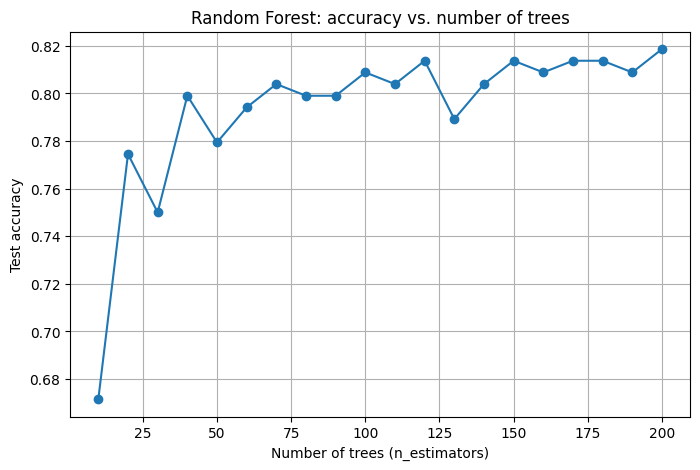

In [32]:
import matplotlib.pyplot as plt

n_trees_range = np.linspace(10, 200, 20, dtype=int)  # 20 values from 10 to 200
accuracies = []

for n_trees in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(n_trees_range, accuracies, marker='o')
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Test accuracy")
plt.title("Random Forest: accuracy vs. number of trees")
plt.grid(True)
plt.show()

3. If we had picked the amount of decision trees by taking the value with the best test accuracy from the last plot, we would have *overfit* our hyperparameters to the test data. Can you see why it is a mistake to tune hyperparameters of your model by using the test data?

If we picked the number of trees with the highest accuracy on this plot (e.g. the
peak around 200, or the local peak around 120), we would be choosing a hyperparameter
based on how well the model happens to perform on this *specific* test set --
including whatever random noise/variance is present in that particular split. This
is a form of overfitting, but at the hyperparameter level instead of the model
parameter level: we would be indirectly "fitting" our modeling choices to the test
set's particular quirks, rather than to the true underlying pattern in the data.

As a result, the reported test accuracy would no longer be an honest, unbiased
estimate of how the model generalizes to genuinely new data -- it would be optimistic,
because the test set was used (even if only implicitly, through hyperparameter
selection) as part of the model-building process. This is exactly why a separate
validation set is needed: hyperparameters should be tuned using validation
performance, and the test set should only be touched once, at the very end, to get a
final, honest generalization estimate.

4. Reshuffle and resplit the data so that it is divided in 3 parts: training (80%), validation (10%) and test (10%). Repeatedly train a model of your choosing (e.g random forest) on the training data, and evaluate it’s performance on the validation set, while tuning the hyperparameters so that the accuracy on the validation set increases. Then, finally evaluate the performance of your model on the test data. What can you say in terms of the generalization of your model?

In [33]:
# Step 1: split into train (80%) and temp (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: split temp into validation (10%) and test (10%) -- i.e. 50/50 of the 20%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (816, 1024)
Validation: (102, 1024)
Test: (102, 1024)


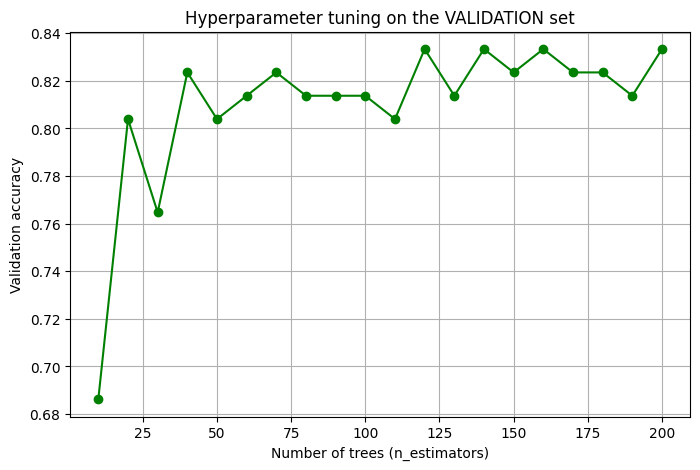

Best n_estimators (chosen via validation): 120


In [34]:
n_trees_range = np.linspace(10, 200, 20, dtype=int)
val_accuracies = []

for n_trees in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(n_trees_range, val_accuracies, marker='o', color='green')
plt.xlabel("Number of trees (n_estimators)")
plt.ylabel("Validation accuracy")
plt.title("Hyperparameter tuning on the VALIDATION set")
plt.grid(True)
plt.show()

# Pick the best number of trees based on validation performance
best_n_trees = n_trees_range[np.argmax(val_accuracies)]
print("Best n_estimators (chosen via validation):", best_n_trees)

In [35]:
final_rf = RandomForestClassifier(n_estimators=best_n_trees, random_state=42)
final_rf.fit(X_train, y_train)

y_test_pred = final_rf.predict(X_test)
final_test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Final model ({best_n_trees} trees) — Test accuracy: {final_test_accuracy}")

Final model (120 trees) — Test accuracy: 0.7941176470588235


The model selected via validation (120 trees, validation accuracy ~0.835) achieves
0.794 accuracy on the held-out test set — a drop of about 4 percentage points. This
gap is expected: because the number of trees was chosen specifically to maximize
validation accuracy, that validation score is somewhat optimistic (it reflects, in
part, how well 120 trees happen to fit this particular validation split, not just the
true underlying pattern). The test accuracy, since it played no role in any decision,
gives a more honest estimate of how the model would perform on genuinely new data.

With only 102 samples each in validation and test, some of this 4-point gap is also
likely just sampling noise rather than genuine overfitting to the validation set —
a useful reminder that small held-out sets give fairly noisy accuracy estimates on
their own.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | TPOT

The process of picking a suitable model, evaluating its performance and tuning the hyperparameters is very time consuming. A new idea in machine learning is the concept of automating this by using an optimization algorithm to find the best model in the space of models and their hyperparameters. Have a look at [TPOT](https://github.com/EpistasisLab/tpot), an automated ML solution that finds a good model and a good set of hyperparameters automatically. Try it on this data, it should outperform simple models like the ones we tried easily. Note that running the algorithm might take a while, depending on the strength of your computer. 

*Note*: In case it is running for too long, try checking if the parameters you are using when calling TPOT are reasonable, i.e. try reducing number of ‘generations’ or ‘population_size’. TPOT uses cross-validation internally, so we don’t need our own validation set.

In [ ]:
from tpot import TPOTClassifier
from sklearn.model_selection import train_test_split
import time

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tpot = TPOTClassifier(
    generations=5,
    population_size=20,
    verbose=2,
    random_state=42,
    n_jobs=1
)

start = time.time()
tpot.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\nTPOT training time: {elapsed:.1f} seconds")

/home/ruben/uni/cuarto/data-science/exercises/venv/lib/python3.10/site-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
/home/ruben/uni/cuarto/data-science/exercises/venv/lib/python3.10/site-packages/distributed/node.py:195: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42199 instead
  warnings.warn(
/home/ruben/uni/cuarto/data-science/exercises/venv/lib/python3.10/site-packages/tpot/tpot_estimator/estimator.py:537: UserWarning: Labels are not encoded as ints from 0 to N. For compatibility with some classifiers such as sklearn, TPOT has encoded y with the sklearn LabelEncoder. When using pipelines outside the main TPOT estimator class, you can encode the labels with est.label_encoder_
  warnings

In [40]:
from sklearn.metrics import accuracy_score

y_pred_raw = tpot.predict(X_test)
y_pred = tpot.label_encoder_.inverse_transform(y_pred_raw)

test_accuracy = accuracy_score(y_test, y_pred)
print("TPOT test accuracy:", test_accuracy)

TPOT test accuracy: 0.8578431372549019


## Results

TPOT (5 generations, population size 20, sequential execution) achieved a test
accuracy of **0.8578** after approximately 70 minutes of training, slightly
outperforming both the logistic regression baseline from week 3 (0.848) and the
random forest models from Exercise 2 of this week (0.770 untuned, 0.794 tuned via
validation).

This matches the expectation that AutoML should be able to find a model at least as
good as, and typically better than, manually-tried simple baselines -- though in this
case the improvement over logistic regression is modest (about 1 percentage point).
The main trade-off is computational cost: TPOT took roughly 70 minutes to search the
pipeline space with n_jobs=1 (sequential, to avoid a Dask/distributed worker error
encountered with n_jobs=-1), versus seconds for fitting a single logistic regression
model. For this dataset, the manual baseline was already quite competitive, so the
main practical benefit of TPOT here is confidence that a substantially better simple
model wasn't being missed, rather than a large accuracy gain.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**